# Stage 4 — cross-condition & cross-region alignment

Procrustes disparity + CCA on **position-binned centroids** (one matched point
per shared spatial bin), from `src/04_cross_condition.py`.

Two comparisons per subject/method:
- **novel vs. familiar** within a region — the geometric transformation
- **CA1 vs. PFC** within a condition — cross-region relationship

**Read CEBRA with care:** it is behavior-aligned (trained on position), so it
maps matched locations to matched embedding coordinates *by construction* —
its low disparity partly reflects that, not neural similarity. The **unsupervised**
embeddings (UMAP/Isomap) give the honest estimate of how much the maps actually
share.


## Setup

In [1]:
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "common" / "config.py").exists())
for _d in ("common", "000447"):
    sys.path.insert(0, str(_root / "src" / _d))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from importlib import import_module
from config import processed_dir, BIN_SIZE_S
DATA_PROCESSED = processed_dir("000447")
BIN_MS = int(BIN_SIZE_S * 1000)
plt.rcParams["figure.dpi"] = 100
METHODS = ["cebra", "umap", "isomap"]

## Load results from all methods

In [2]:
frames = []
for m in METHODS:
    f = DATA_PROCESSED / f"stage4_alignment_{m}_{BIN_MS}ms.csv"
    if f.exists():
        frames.append(pd.read_csv(f))
df = pd.concat(frames, ignore_index=True)
print("comparisons:", len(df))
df.groupby(["method", "comparison"]).agg(
    disparity=("procrustes_disparity", "mean"),
    null=("null_mean", "mean"),
    cca_r=("cca_mean_r", "mean"),
    frac_sig=("p_value", lambda s: (s < 0.05).mean()),
).round(3)

comparisons: 75


disparity   null  cca_r  frac_sig
method comparison                                          
cebra  CA1_vs_PFC             0.119  0.956  0.905     1.000
       novel_vs_familiar      0.160  0.925  0.872     1.000
isomap CA1_vs_PFC             0.646  0.962  0.503     1.000
       novel_vs_familiar      0.773  0.939  0.385     0.500
umap   CA1_vs_PFC             0.701  0.964  0.492     0.933
       novel_vs_familiar      0.771  0.942  0.395     0.600

## 1. Procrustes disparity: observed vs. shuffled null

Lower = more similar geometry. Bars are the observed disparity (mean±sd across
comparisons); the grey line is the shuffled-null mean (chance). A bar well below
the null line means the two geometries share real structure.

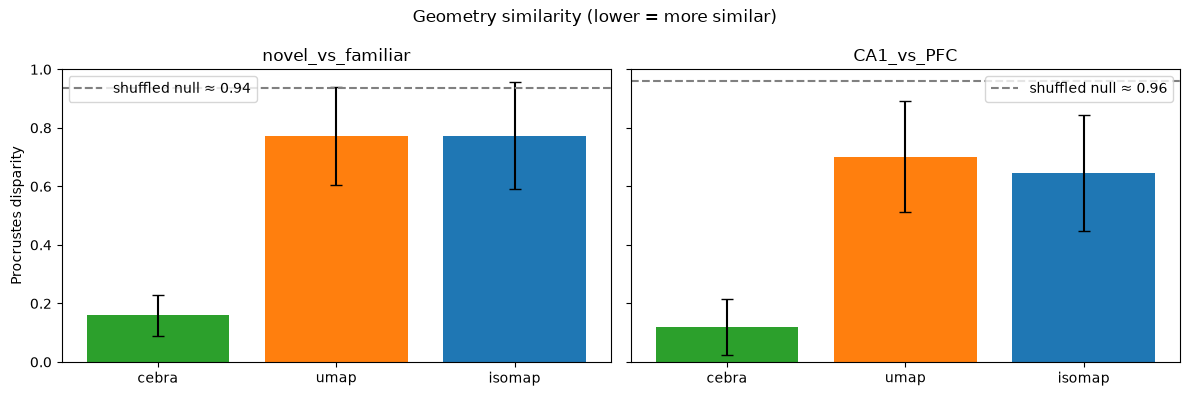

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, comp in zip(axes, ["novel_vs_familiar", "CA1_vs_PFC"]):
    sub = df[df["comparison"] == comp]
    g = sub.groupby("method")["procrustes_disparity"]
    means, sds = g.mean().reindex(METHODS), g.std().reindex(METHODS)
    x = np.arange(len(METHODS))
    ax.bar(x, means, yerr=sds, capsize=4,
           color=["tab:green", "tab:orange", "tab:blue"])
    null = sub["null_mean"].mean()
    ax.axhline(null, color="grey", ls="--", label=f"shuffled null ≈ {null:.2f}")
    ax.set_xticks(x); ax.set_xticklabels(METHODS)
    ax.set_title(comp); ax.set_ylim(0, 1); ax.legend()
axes[0].set_ylabel("Procrustes disparity")
fig.suptitle("Geometry similarity (lower = more similar)")
plt.tight_layout()

## 2. CCA canonical correlation
Higher = the two point-sets are more linearly related.

comparison,CA1_vs_PFC,novel_vs_familiar
method,,
cebra,0.905,0.872
umap,0.492,0.395
isomap,0.503,0.385


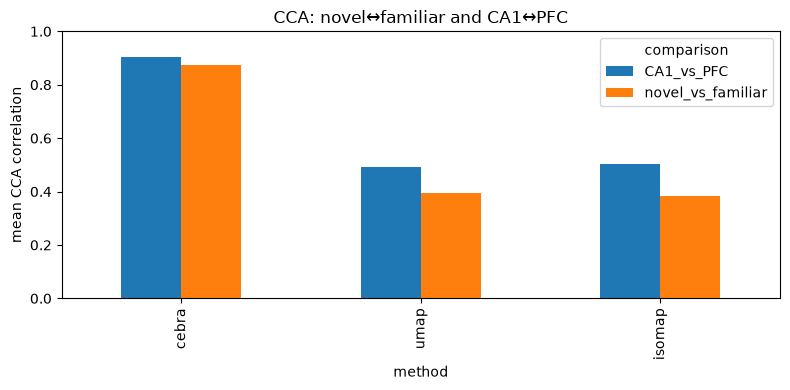

In [4]:
piv = df.pivot_table(index="method", columns="comparison",
                     values="cca_mean_r", aggfunc="mean").reindex(METHODS)
ax = piv.plot.bar(figsize=(8, 4)); ax.set_ylabel("mean CCA correlation")
ax.set_title("CCA: novel↔familiar and CA1↔PFC"); ax.set_ylim(0, 1)
plt.tight_layout(); piv.round(3)

## 3. Visualize a transformation

Novel (red) vs familiar (blue) position-centroids for one subject/region, after
Procrustes alignment. CEBRA (top) vs UMAP (bottom) — CEBRA collapses the two
maps together (position baked in); UMAP shows how much they genuinely differ.

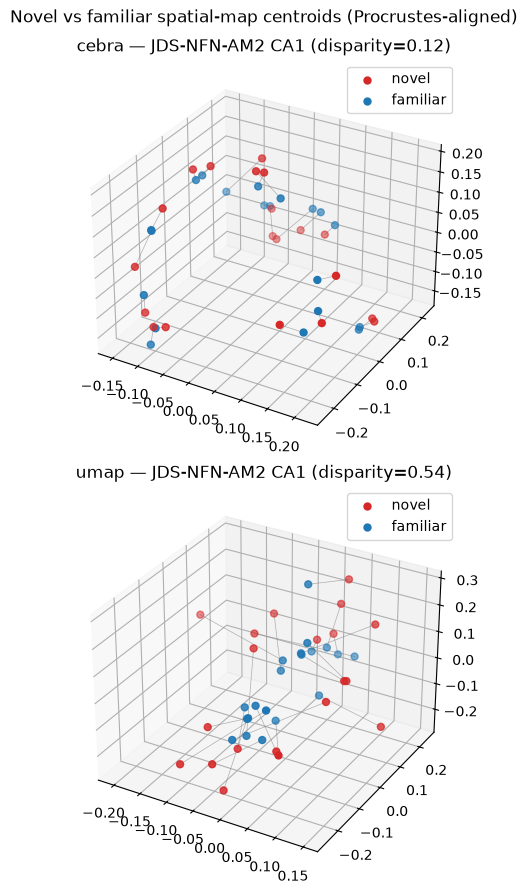

In [5]:
from scipy.spatial import procrustes
from config import spatial_grid_labels
s4 = import_module("04_cross_condition")

SUBJECT = sorted({f.stem.split('_')[2] for f in DATA_PROCESSED.glob(f'emb_cebra_*_{BIN_MS}ms.npz')})[0]
REGION = "CA1"
fig = plt.figure(figsize=(10, 9))
for row, method in enumerate(["cebra", "umap"]):
    d = np.load(DATA_PROCESSED / f"emb_{method}_{SUBJECT}_{REGION}_{BIN_MS}ms.npz", allow_pickle=False)
    lab = spatial_grid_labels(d["position"], s4.N_GRID)
    cond = d["condition"]; nov, fam = cond == "novel", cond == "familiar"
    bins = s4._shared_bins(lab, [nov, fam])
    A = s4._centroids(d["embedding"], lab, nov, bins)
    B = s4._centroids(d["embedding"], lab, fam, bins)
    mA, mB, disp = procrustes(A, B)
    ax = fig.add_subplot(2, 1, row + 1, projection="3d")
    ax.scatter(mA[:, 0], mA[:, 1], mA[:, 2], color="tab:red", s=25, label="novel")
    ax.scatter(mB[:, 0], mB[:, 1], mB[:, 2], color="tab:blue", s=25, label="familiar")
    for a, b in zip(mA, mB):
        ax.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]], color="grey", lw=0.5, alpha=0.6)
    ax.set_title(f"{method} — {SUBJECT} {REGION} (disparity={disp:.2f})"); ax.legend()
fig.suptitle("Novel vs familiar spatial-map centroids (Procrustes-aligned)")
plt.tight_layout()

## 4. Embedding robustness — novel↔familiar at 50 ms (linearized), CEBRA vs. UMAP

The headline (novel and familiar are different mazes → compare at matched
track-relative positions) should not depend on the embedding. Below, the
**linearized** novel↔familiar disparity across UMAP, unsupervised CEBRA-Time, and
supervised CEBRA (50 ms path). The two unsupervised methods agree (≈0.55–0.59, far
below the ~0.90 null); supervised CEBRA reads lower because position is baked in.

,method,disparity,null,cca_r,frac_sig
0,UMAP (unsup),0.585,0.906,0.559,0.8
1,CEBRA-Time (unsup),0.548,0.897,0.562,0.8
2,CEBRA (sup),0.484,0.890,0.670,0.9


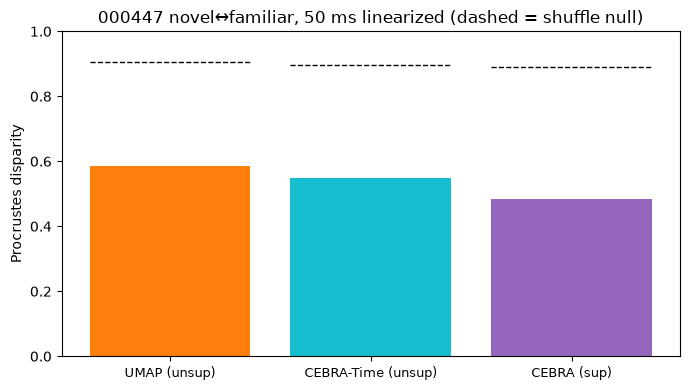

In [6]:
# CEBRA vs. UMAP — novel<->familiar at 50 ms, LINEARIZED (arm-matched)
methods50 = ["umap", "cebratime", "cebra"]
mlab = {"umap": "UMAP (unsup)", "cebratime": "CEBRA-Time (unsup)", "cebra": "CEBRA (sup)"}
rows = []
for m in methods50:
    f = DATA_PROCESSED / f"stage4b_linearized_{m}.csv"
    if f.exists():
        d = pd.read_csv(f)
        rows.append((mlab[m], d.procrustes_disparity.mean(), d.null_mean.mean(),
                     d.cca_mean_r.mean(), (d.p_value < 0.05).mean()))
comp = pd.DataFrame(rows, columns=["method", "disparity", "null", "cca_r", "frac_sig"])
fig, ax = plt.subplots(figsize=(7, 4)); x = np.arange(len(comp))
ax.bar(x, comp.disparity, color=["tab:orange", "tab:cyan", "tab:purple"][:len(comp)])
for i, nmean in enumerate(comp.null):
    ax.plot([i - 0.4, i + 0.4], [nmean, nmean], "k--", lw=1)
ax.set_xticks(x); ax.set_xticklabels(comp.method, fontsize=9)
ax.set_ylim(0, 1); ax.set_ylabel("Procrustes disparity")
ax.set_title("000447 novel↔familiar, 50 ms linearized (dashed = shuffle null)")
plt.tight_layout()
comp.round(3)

---
**Takeaway pattern:** unsupervised embeddings show novel↔familiar disparity well
below chance but far from zero — the map is **partially preserved and partially
transformed**, not a rigid copy nor a full remap. Stage 5 (topology) checks
whether ring/toroidal structure is retained across the transformation.